# Chapter 1. Basics and Core Workflow of Qiskit

## 1. Introduction

% Add introductory sentences.


You can run this notebook from top to bottom in a fresh Google Colab runtime, or run locally.

### 1.1. Set up

To run this notebook in Google Colab, you'll need a **Google account** so you can open notebooks and execute cells in the browser.

To run on a real IBM quantum computer, you'll also need a (free) [**IBM Quantum® Platform account**](https://quantum.cloud.ibm.com/signin?redirectTo=%2F).
You can open an instance using the Open Plan to get 10 minutes of quantum processor unit (QPU) time per 28-day rolling window, which actually is quite a lot!
*If you have trouble with your account, see the [Support page](https://quantum.cloud.ibm.com/docs/en/guides/support).*

You can also run this notebook locally after installing Qiskit by following the instructions on [**IBM Quantum Platform**](https://quantum.cloud.ibm.com/docs/en/guides/install-qiskit).

#### Installation and imports

In Colab, we install dependencies inside the notebook so everyone runs the same tools.
The next cell installs Qiskit with the [visualization module](https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization) plus two add-ons: **Aer** (fast simulators) and the **IBM Runtime** client (for quantum computer runs).

Next, we import the main tools used in this tutorial:

- `QuantumCircuit`: defines qubits and quantum operations.
- `plot_histogram`: visualizes measurement results.
- `AerSimulator`: simulates quantum circuits on a classical computer.
- `preset_passmanagers`: optimizes circuits for quantum hardware.
- `Sampler` and `QiskitRuntimeService`: run circuits on real quantum computers through Qiskit Runtime.


In [12]:
COLAB = False

if COLAB:
    # Colab setup
    from pathlib import Path
    from urllib.request import urlretrieve
    import sys

    DOWNLOAD_DIR = Path(".")
    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

    def _download(url: str, dst: Path) -> None:
        dst.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading {url} -> {dst}')
        urlretrieve(url, dst)

    resolved_download_dir = str(DOWNLOAD_DIR.resolve())
    if resolved_download_dir not in sys.path:
        sys.path.insert(0, resolved_download_dir)

    _download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/utils.py", Path("utils.py"))
    _download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/linear_h_chains_jw.json", Path("linear_h_chains_jw.json"))
    _download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/requirements.txt", Path("requirements.txt"))

In [13]:
!pip install -r requirements.txt

In [14]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

Next we'll do a quick environment check. We confirm versions and confirm imports.

If anything fails here, it's usually a dependency install issue; fixing it now prevents confusing errors later.



In [15]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.10
qiskit: 2.3.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.45.1


#### Save IBM Account

![IQP_login.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/IQP_login.png)
1. Login [IBM Quantum Platform](https://quantum.cloud.ibm.com/).
2. Create and copy API Key.
3. Assign the key to `api_token` variable in the next cell
4. Go to [Compute Resource tap](https://quantum.cloud.ibm.com/computers) and check the available backends.


In [16]:
try:
    service = QiskitRuntimeService()
except Exception:
    api_token = "Your_Token_Here"  # Replace with your actual API token
    QiskitRuntimeService.save_account(
        token=api_token,
        overwrite=True
    )
    service = QiskitRuntimeService()

backend_name = "ibm_boston"

qiskit_runtime_service.__init__:WARNING:2026-05-02 23:11:48,677: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().



--------

## 2. Create and run a quantum program using Qiskit

### 2.1. Build a Simple Quantum Circuit


<div class="alert alert-block alert-info">
For those who are not familiar with the concept of qubits and quantum circuits, visit
<a>https://quantum.cloud.ibm.com/composer</a>
and browse the guided tutorial from the menu:
<b>Help → Build your first circuit</b>.
</div>

We're going to generate the entangled state called the **$\Phi^+$ (phi-plus) Bell state**:

$$
|\Phi^+\rangle = \frac{1}{\sqrt 2}{|00\rangle + |11\rangle}.
$$

To build the Bell state circuit, we use an $H$ (Hadamard) gate to put the first qubit into an equal superposition.
Then we apply a $CX$ (controlled-NOT) gate, which entangles the two states together.

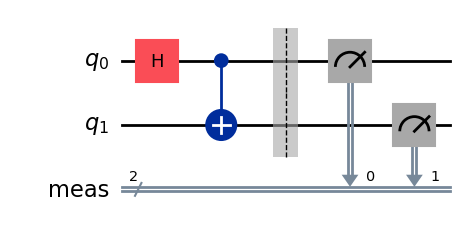

In [17]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

display(bell.draw("mpl"))

#### Helper function for running circuits

Now let's define a helper function that handles the process of running a quantum circuit and retrieving measurement results. This function takes care of transpiling the circuit to match the backend's instruction set, running it through a `Sampler` primitive, and extracting the counts from the results.



In [18]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

### 2.2. Run on a QPU and visualize results

Finally, we run the circuit on an IBM quantum processing unit (QPU) in the cloud for 1000 shots and plot the results. IBM QPUs are physical systems that can pick up noise, so gates are slightly imperfect, measurements can be wrong sometimes, and device calibration drifts over time.

Running on real quantum computers also introduces practical considerations. Jobs can sit in a queue, because many people may be using the same device. You also have to choose a shot count that balances statistical considerations (more shots equals a higher signal-to-noise ratio) with time/cost constraints.

Follow the instructions in the code comments of the next cell. After running the cell, you should see a histogram with approximately equal counts for the $00$ and $11$ bitstrings, with some occurrences of $01$ or $10$ due to noise. The following cell in this notebook runs the same circuit on a simulator, should you choose to skip running on a QPU.



In [19]:
# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
backend = service.backend(backend_name)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-05-02 23:12:09,788: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-02 23:12:09,789: Using instance: Solutions Notebooks premium fleet, plan: premium


ibm_boston


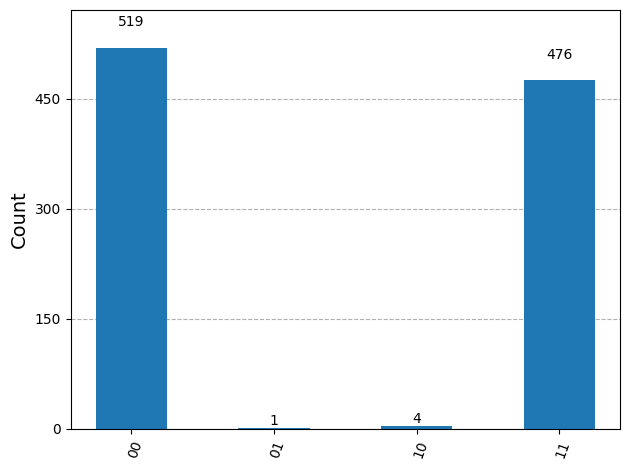

In [20]:
counts_real_backend = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts_real_backend)

### 2.3. Run on a simulator and visualize results

A simulator is a "perfect world" version of quantum computing. Here we run the circuit on a simulator for 1000 shots and plot the results. You should see approximately equal counts for the $00$ and $11$ states, with no occurrences of $01$ or $10$, which is the signature of the Bell state's perfect correlation.



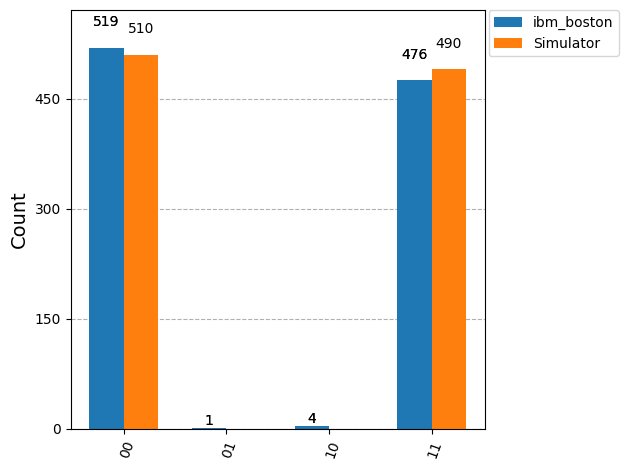

In [21]:
simulator_backend = AerSimulator()
counts_simulator = run_circuit_and_get_counts(bell, simulator_backend, shots=1000)

plot_histogram([counts_real_backend, counts_simulator], legend=[backend_name, "Simulator"])

#### Check your understanding

<div class="alert alert-block alert-success">
<b> Exercise 1. </b> Answer to the following questions.
</div>

Q1. What are the two gates that create the Bell state here?

<details>
    An H gate on qubit 0, followed by a CX gate with qubit 0 as control and qubit 1 as target.
</details>

Q2. On an ideal simulator, which two bitstrings should dominate the histogram?

<details>
    00 and 11 should dominate.
</details>

Q3. Why wouldn't a perfect simulator always have the exact same number of 00 counts as 11 counts?

<details>
    Even though a simulator is "perfect" and leads to a perfect Bell state, it is still simulating an inherently random process, so statistical fluctuations will still occur. It's like flipping a coin 1000 times: even if there is an exact 50-50 chance of the coin landing on heads or tails, that doesn't mean you'll always get exactly 500 instances of heads and 500 of tails.
</details>

Q3. Why might a real quantum computer show some 01 or 10 results even though the simulator didn't?

<details>
    Because real devices have noise. Gates and measurements are not perfect, and that can introduce occasional errors.
</details>

Q4. What is one practical difference between simulators and real quantum computers besides noise?

<details>
    Quantum computers can involve queue time, limited availability, and device-specific constraints that affect how circuits run.
</details>



<div class="alert alert-block alert-success">
<b> Exercise 2. </b> Write a code that prepares 3-qubit GHZ state and samples with the backend and simulator.
</div>

$$
|\Psi_{\rm GHZ}\rangle = \frac{1}{\sqrt 2}{|000\rangle + |111\rangle}
$$

Suggested steps:

1. create a 3-qubit circuit,
2. apply `H` to qubit 0,
3. apply two `CX` gates to spread the entanglement (`cx(0, 1)` and `cx(1, 2)`).
4. measure all qubits,
5. run the circuit with `run_circuit_and_get_counts` helper function.
6. show the histogram plot usint `plot_histogram`.


In [22]:
# Your Code Here

<details>
<pre><code class="language-python">

qc_ghz = QuantumCircuit(3)
qc_ghz.h(0)
qc_ghz.cx(0,1)
qc_ghz.cx(1,2)
qc_ghz.measure_all()
display(qc_ghz.draw("mpl"))

counts_simulator_ghz = run_circuit_and_get_counts(bell, simulator_backend, shots=1000)
counts_backend_ghz = run_circuit_and_get_counts(bell, backend, shots=1000)

display(plot_histogram([counts_real_backend, counts_simulator], legend=[backend_name, "Simulator"]))

</code></pre>


------

## 3. Quantum Experiments with Qiskit and Qiskit Patterns

#### Quantum Simulation of Spin Systems

![quantum_simulation.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/quantum_simulation.png)


Now, we'll focus on a problem in the domain of **nature simulation**: using a quantum computer as a controllable stand-in for a natural quantum system.

Specifically, we will simulate the interaction between two spins, which you can think of as **tiny magnets**.
Depending on the sign of their interaction, they might prefer to
- *align* and point in the same direction, or
- *anti-align* and point in opposite directions.

Once we understand this small two-qubit system, we'll show how the same ideas scale up, allowing quantum computers to take advantage of their exponential scaling when simulating large spin systems.

#### Qiskit Pattern

In this section, we will organize the workflow using the **Qiskit pattern**.

| Step | General idea | In our spin problem |
|---|---|---|
| **1. Map** | Express the problem as quantum circuits and operators. | Write the spin Hamiltonian as a qubit operator and prepare a two-qubit state. |
| **2. Optimize** | Convert the circuit into a form suitable for the target backend. | Optimize the circuit so it can run efficiently on the selected backend. |
| **3. Execute** | Run the circuit on a simulator or quantum computer. | Execute the circuit to measure the energy. |
| **4. Postprocess** | Analyze the measurement results to extract the answer. | Simply prints the measured energy. |

This pattern is useful because quantum experiments are not just about writing circuits.
We also need to map the problem, prepare the circuit for hardware, run it, and interpret the results.

Even though this example uses only two qubits, the same pattern is used in larger quantum simulation workflows and other quantum applications.

### 3.1 Two Interacting Magnets

For this problem, we're going to use two qubits, one for each spin in our model. Each spin can be pointing up (qubit state $|0\rangle = |\uparrow\rangle$), down (qubit state $|1\rangle = |\downarrow\rangle$), or in a superposition of the two states.

If the spins have an *antiferromagnetic* interaction, it means they want to anti-align, so when one is up, the other wants to be down, and vice-versa.

Now suppose there is also a magnetic field pointing from left to right in our system. Because this field points across the usual up-down direction of the spins, it is called a transverse field. This field can flip spins, which causes the lowest energy configuration to be a specific superposition of up-and-down spin arrangements rather than any single definite spin pattern.

We can describe all of these effects using a mathematical object called a Hamiltonian. The Hamiltonian tells us the energy of the system for a given arrangement of spins:

$$
H = J Z_1 Z_0 + h_x (X_1 + X_0)
$$

where $J$ is a coefficient controlling the strength of the interaction between spins and $h_x$ is a coefficient for the strength of the external magnetic field. $Z_1 Z_0$ rewards or penalizes the spins depending on whether they are aligned or anti-aligned, and $X_0$ and $X_1$ represent the spin-flipping effect of the magnetic field.

In physics, systems tend to settle into the state with the lowest possible energy, called the ground state. Finding this lowest-energy state is a common problem, but it requires optimization techniques that are beyond the scope of this lesson.

Instead, we will ask a simpler question: If we prepare the spins in a particular state, what is the energy of that state?

To answer this, we will:

1. Prepare the spins in a state of our choosing
2. Measure the energy of that state using the Hamiltonian above

This is exactly the kind of calculation that appears inside larger quantum algorithms, such as variational algorithms, which you can explore in later courses.